<table style="width:100%">
  <tr>
    <td valign="top"><img src="https://github.com/mgrubisic/ai_bootcamp_foundations/blob/main/data/img/FER_logo_2.png?raw=1" width=300 height=80 align="left"></td>
    <td valign="top"><img src="https://github.com/mgrubisic/ai_bootcamp_foundations/blob/main/data/img/LARES_2_transparent.png?raw=1" width=250 height=80 align="right"></td>
  </tr>
 </table>

# Unsupervised learning

## Setup

Run this cell first, in every notebook. It fetches the course repository into
the Colab session and moves into the `notebooks/` folder, so that the
`../data/...` paths work.

It is safe to run more than once, and safe after a restart.

Note: outside Colab the cell does nothing except report the working directory.
Start Jupyter from inside `notebooks/` and the paths work the same way.

If it prints `data ok: True`, we are set.

In [1]:
# --- SETUP: run this first ---
# works in Colab and locally, safe to run more than once
import os, sys, subprocess
REPO = "ai_bootcamp_foundations"
if "google.colab" in sys.modules:
    if not os.path.isdir(f"/content/{REPO}"):
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/mgrubisic/{REPO}.git"],
                       cwd="/content", check=True)
    os.chdir(f"/content/{REPO}/notebooks")
print("cwd:", os.getcwd(), "| data ok:", os.path.isdir("../data"))

cwd: /content/ai_bootcamp_foundations/notebooks | data ok: True


## Import modules

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
import matplotlib.pyplot as plt

tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": False,
    "font.family": "serif",
    # Use 26pt font in plots
    "axes.labelsize": 16,
    "font.size": 16,
    "figure.titlesize": 16,
    # Make the legend/label fonts a little smaller
    "legend.title_fontsize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
}

plt.rcParams.update(tex_fonts)

#%pylab inline
%matplotlib inline
# %matplotlib notebook
%config InlineBackend.figure_format='svg'
plt.rcParams['figure.figsize'] = (10, 7)

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Auxiliary functions

In [5]:
# aux function for elbow method implementation
def elbow_method(X_train, n):
    wcss = []
    # calculate Within Cluster Sum of Squares (WCSS) for KMeans with 1-n clusters
    for i in range(1, n):
        kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
        kmeans.fit(X_train)
        wcss.append(kmeans.inertia_)

    fig = plt.figure(figsize = (10, 7))

    plt.plot(range(1, n), wcss)
    plt.title('The Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.show()

In [17]:
# aux function for plotting data with characterized clusters
def plot_clusters(X_train, y_kmeans, feat_1, feat_2):
    fig = plt.figure(figsize = (8, 8))
    for i, cluster_center in enumerate(model_kmeans.cluster_centers_):
        plt.scatter(X_train[y_kmeans == i, 0], X_train[y_kmeans == i, 1], s = 100, label = 'Cluster '+str(i+1))

    plt.scatter(model_kmeans.cluster_centers_[:, 0], model_kmeans.cluster_centers_[:, 1], s = 100, c = 'k', marker='x', label = 'Centroids')

    plt.title('Clusters')
    plt.xlabel(feat_1)
    plt.ylabel(feat_2)
    plt.grid(True)
    plt.legend()
    plt.show()

In [7]:
# aux function for plotting PCA features
def plot_pca_component(pca_features, component_num):
    first_comp = pca_features[:, component_num]
    comps = pd.DataFrame(list(zip(first_comp, X_scaled.columns)), columns=["weights", "features"])
    comps["abs_weights"] = comps["weights"].apply(lambda x: np.abs(x))
    ax = sns.barplot(data=comps.sort_values("abs_weights", ascending=False).head(10),
                     x="weights",y="features",palette="Blues_d")
    ax.set_title("PCA Component Makeup: #" + str(component_num))
    plt.show()

## Unsupervised learning
0. Preprocess data

1. K-means clustering

2. Hierarchical clustering

3. Principal component analysis

4. HANDS-ON: clustering with reduced dimensionality


## 0. (Pre)process data

Let's start with a simple presentation example and consider a dataset of mall customers and their characteristics: spending score and annual income.

Dataset available at: https://www.kaggle.com/shwetabh123/mall-customers

In [8]:
dataset = pd.read_csv('../data/mall_customers/mall_customers.csv')

In [9]:
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


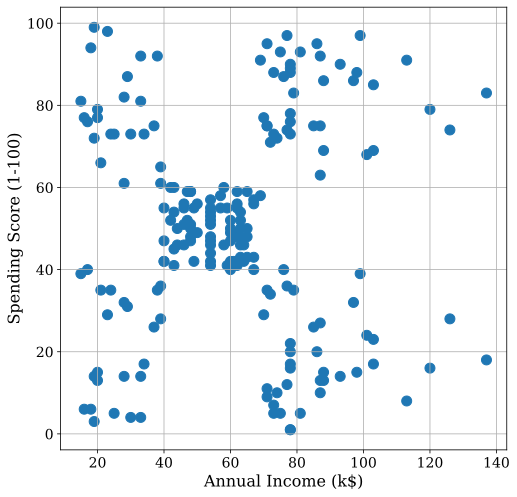

In [13]:
# choose only 'Annual Income (k$)' and 'Spending Score (1-100)' columns
X_train = dataset.loc[:, ['Annual Income (k$)', 'Spending Score (1-100)']].values
# simple scatter plot to visualize the data distribution
fig = plt.figure(figsize = (8, 8))
plt.scatter(X_train[:,0],X_train[:,1], s = 100)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

## 1. K-means clustering

### Use the elbow method to find the optimal number of clusters

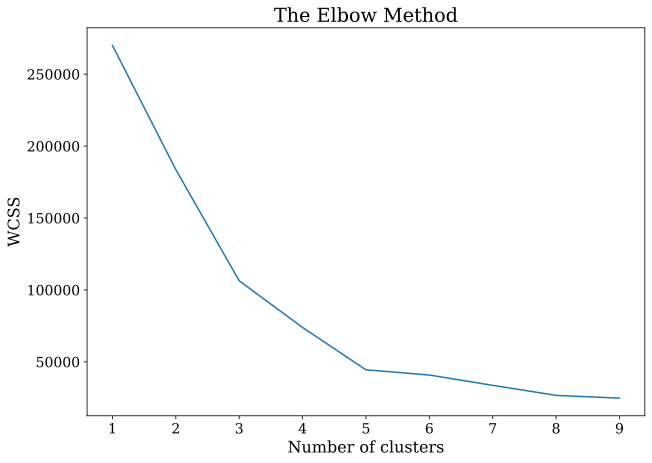

In [14]:
# elbow method up to 10 clusters
elbow_method(X_train, 10)

### Training the K-Means model on the dataset - based on the elbow method results

In [15]:
# train K-Means model with 5 clusters (elbow method)
model_kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = model_kmeans.fit_predict(X_train)

### Visualize the clusters

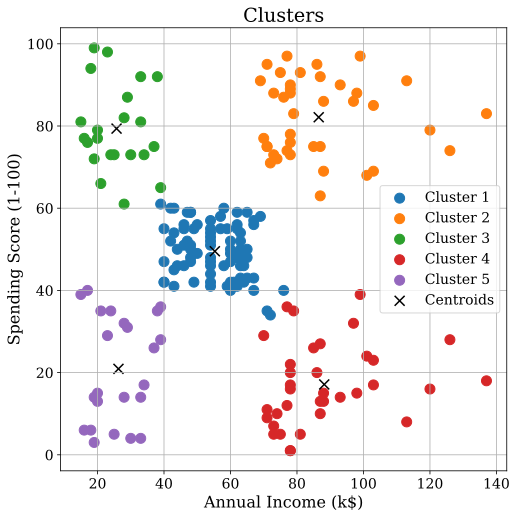

In [18]:
# plot the characterized clusters
plot_clusters(X_train, y_kmeans, 'Annual Income (k$)', 'Spending Score (1-100)')

## 2. Hierarchical clustering

In [19]:
"""
Perform hierarchical clustering on samples using the
linkage() function with the method='complete' keyword argument.
Assign the result to mergings.
"""
from scipy.cluster.hierarchy import linkage, dendrogram

mergings = linkage(X_train, method='complete')

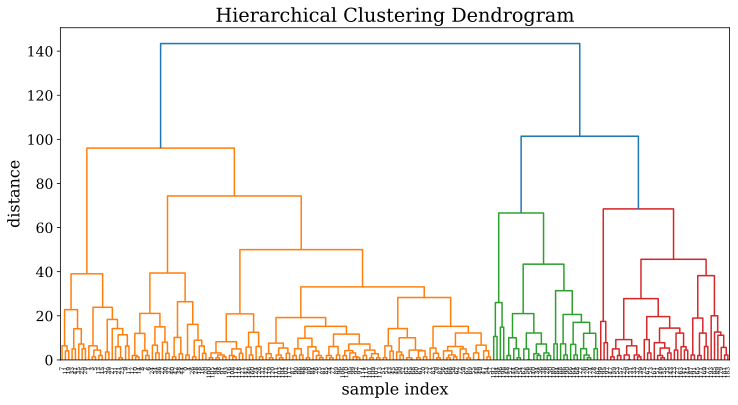

In [21]:
"""
Plot a dendrogram using the dendrogram() function on mergings,
specifying the keyword arguments labels=varieties, leaf_rotation=90,
and leaf_font_size=6.
"""
fig, ax = plt.subplots(figsize = (12,6))

dendrogram(mergings,
           ax=ax,
           leaf_rotation=90,
           leaf_font_size=6,
           )

ax.set_title('Hierarchical Clustering Dendrogram')
ax.set_xlabel('sample index')
ax.set_ylabel('distance')

# ax.set_xlim([0, 1500])

plt.show()

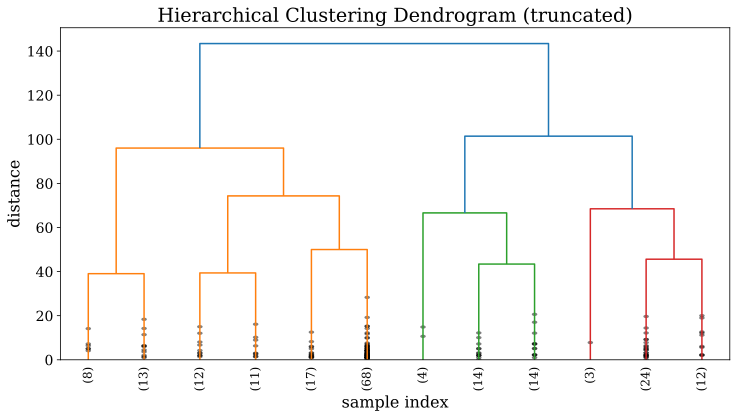

In [22]:
fig, ax = plt.subplots(figsize=(12,6))

dendrogram(
    mergings,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=12,  # show only the last p merged clusters
    show_leaf_counts=True,  # otherwise numbers in brackets are counts
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a distribution impression in truncated branches
)

ax.set_title('Hierarchical Clustering Dendrogram (truncated)')
ax.set_xlabel('sample index')
ax.set_ylabel('distance')

plt.show()

**Exercise:** do the same with other types of linkages (single, complete, average, weighted, centroid, median, ward)
Reference: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html

## 3. Principal component analysis

Firstly, the data: let's use Seeds dataset (UCI ML): https://archive.ics.uci.edu/dataset/236/seeds

The data consists of seven geometric parameters of wheat kernels were measured:
1. area A,
2. perimeter P,
3. compactness C = 4*pi*A/P^2,
4. length of kernel,
5. width of kernel,
6. asymmetry coefficient
7. length of kernel groove.

All of these parameters were real-valued continuous.

In [24]:
# load the data
seeds_df = pd.read_csv("../data/wheat/seeds_dataset.txt", sep="\t", header=None)
seeds_df.rename(columns={0: 'area', 1: 'perimeter', 2: 'compactness', 3: 'kernel_length',
                         4: 'kernel_width', 5: 'asymmetry', 6: 'groove_lenght', 7: 'grain_type'}, inplace=True)
seeds_df

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_lenght,grain_type
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


#### Correlation

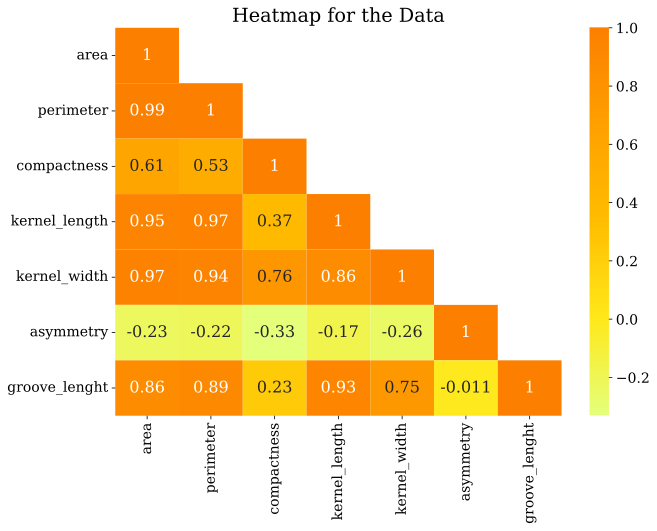

In [25]:
seeds_corr = seeds_df.iloc[:, :-1].corr()

mask = np.zeros_like(seeds_corr, dtype=bool)
mask[np.tril_indices_from(mask)] = True

sns.heatmap(seeds_corr, mask=~mask, cmap='Wistia', annot=True)
plt.title('Heatmap for the Data')
plt.show();

#### Separate input features and corresponding outputs

In [26]:
y = seeds_df['grain_type']
X = seeds_df.drop('grain_type', axis=1)

### Scaling

In [27]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X))
X_scaled.columns = X.columns
X_scaled.index = seeds_df.index

In [28]:
X_scaled.describe()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_lenght
count,2.100000e+02,2.100000e+02,2.100000e+02,2.100000e+02,2.100000e+02,2.100000e+02,2.100000e+02
mean,-3.383537e-16,1.184238e-16,1.285744e-15,-2.097793e-15,-3.383537e-16,-3.383537e-16,-8.987520e-17
std,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00
min,-1.466714e+00,-1.649686e+00,-2.668236e+00,-1.650501e+00,-1.668209e+00,-1.956769e+00,-1.813288e+00
25%,-8.879552e-01,-8.514330e-01,-5.980791e-01,-8.286816e-01,-8.349072e-01,-7.591477e-01,-7.404953e-01
50%,-1.696741e-01,-1.836639e-01,1.039927e-01,-2.376280e-01,-5.733534e-02,-6.746852e-02,-3.774588e-01
75%,8.465989e-01,8.870693e-01,7.116771e-01,7.945947e-01,8.044956e-01,7.123789e-01,9.563941e-01
max,2.181534e+00,2.065260e+00,2.006586e+00,2.367533e+00,2.055112e+00,3.170590e+00,2.328998e+00


## PCA

In [29]:
# Create a PCA instance, fit the data, and transform it
pca = PCA().fit(X_scaled)
pca_features = pca.transform(X_scaled)
pca_features

array([[ 3.17047052e-01, -7.83669015e-01, -6.31010011e-01, ...,
         1.07495661e-01,  2.25704926e-02, -1.46966404e-02],
       [-3.38617773e-03, -1.91321367e+00, -6.69754458e-01, ...,
        -4.44064177e-02,  1.89211651e-02, -5.47935827e-03],
       [-4.59443341e-01, -1.90722525e+00,  9.32488818e-01, ...,
         8.22190426e-03, -5.13130366e-02, -4.17726735e-03],
       ...,
       [-1.40363281e+00,  1.29859258e+00,  2.90581137e+00, ...,
         2.44762377e-02,  8.30322292e-02, -3.23259469e-02],
       [-2.33932776e+00, -9.96986962e-02, -3.82515114e-01, ...,
        -5.83631073e-02, -5.10318121e-02,  1.39518637e-02],
       [-1.95595293e+00,  5.25071183e-01,  1.01311340e+00, ...,
         1.14276307e-01,  1.04496603e-02, -3.67966745e-04]])

### Plot variance for PCA components

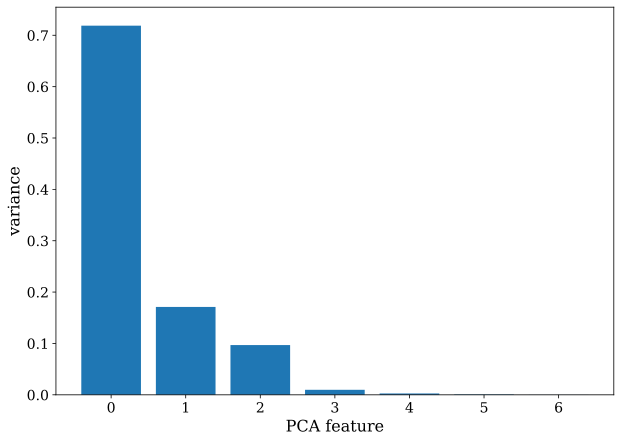

In [30]:
# Plot the explained variances
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_ratio_)
plt.xlabel('PCA feature')
plt.ylabel('variance')
plt.xticks(features)
plt.show()

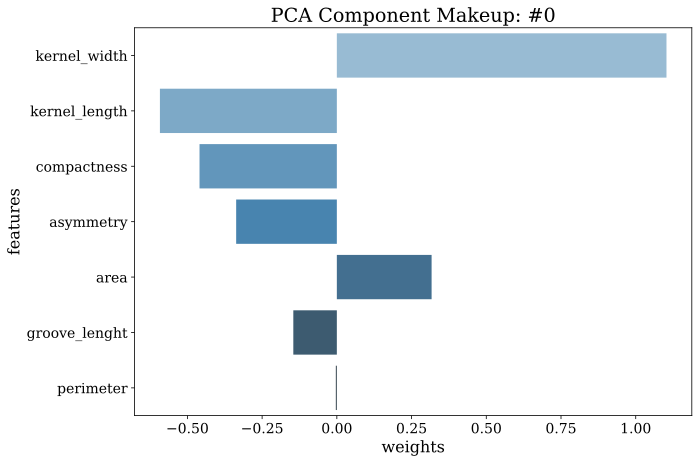

In [31]:
plot_pca_component(pca_features=pca_features, component_num=0)

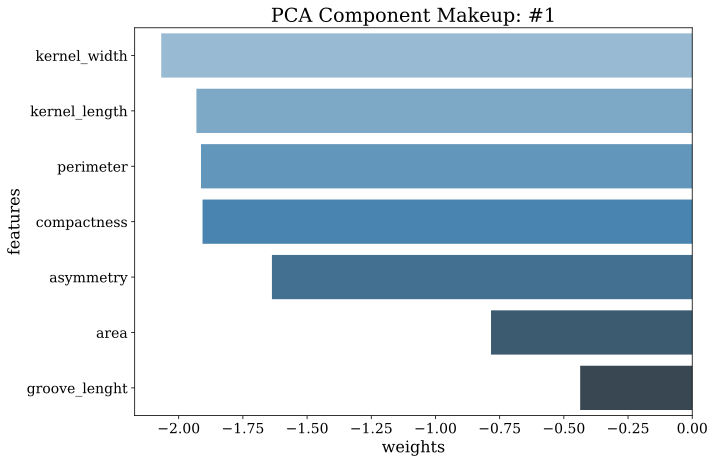

In [32]:
plot_pca_component(pca_features=pca_features, component_num=1)

## 4. HANDS-ON: clustering with reduced dimensionality

The wheat data is transformed using PCA.
Cluster this transformed data and compare with true values (y).

In [33]:
# define the data - use 2 most influential features
X_pca = pca_features[:, :2]

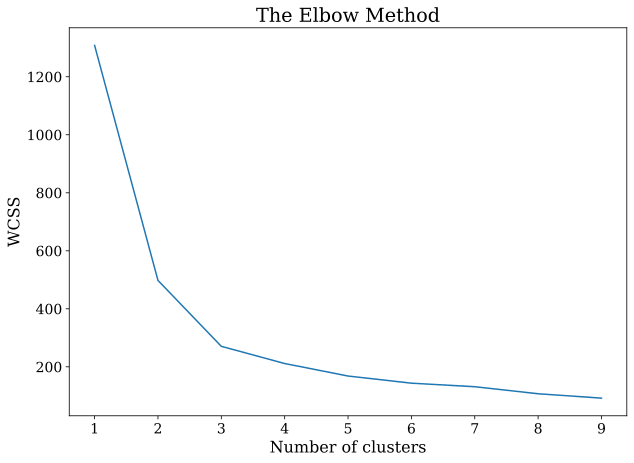

In [40]:
elbow_method(X_pca, 10)

In [34]:
# train the model, random_state=42
model = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_hat = model.fit_predict(X_pca)

In [35]:
# compare with true data
df = pd.DataFrame({
    "true": y,
    "predicted": y_hat,
})
df

,true,predicted
0,1,2
1,1,2
2,1,2
3,1,2
4,1,2
...,...,...
205,3,1
206,3,1
207,3,1
208,3,1


In [36]:
# find out which cluster represent which grain type
for c in range(3):
    for g in range(1, 4):
        N = (df.true[df.predicted==c] == g).sum()
        print(f"Cluster {c} correspond to {N} samples of grain type {g}")

Cluster 0 correspond to 2 samples of grain type 1
Cluster 0 correspond to 65 samples of grain type 2
Cluster 0 correspond to 0 samples of grain type 3
Cluster 1 correspond to 8 samples of grain type 1
Cluster 1 correspond to 0 samples of grain type 2
Cluster 1 correspond to 66 samples of grain type 3
Cluster 2 correspond to 60 samples of grain type 1
Cluster 2 correspond to 5 samples of grain type 2
Cluster 2 correspond to 4 samples of grain type 3


In [37]:
# remap clusters to grain types
def remap(c):
    if c==0:
        return 2
    elif c==1:
        return 3
    elif c==2:
        return 1
    else:
        raise ValueError("Cannot be anything aprt from 0, 1, and 2")

df2 = df.copy()
df2.predicted = df2.predicted.apply(remap)

In [38]:
# get metrics
from sklearn.metrics import classification_report

print(classification_report(df2.true, df2.predicted))

              precision    recall  f1-score   support

           1       0.87      0.86      0.86        70
           2       0.97      0.93      0.95        70
           3       0.89      0.94      0.92        70

    accuracy                           0.91       210
   macro avg       0.91      0.91      0.91       210
weighted avg       0.91      0.91      0.91       210



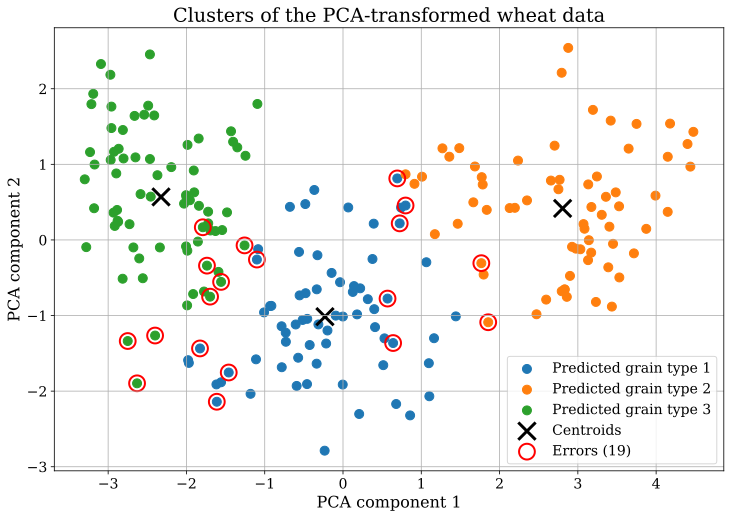

In [39]:
# plot the clusters, their centroids, and the errors
centroids = model.cluster_centers_
errors = (df2.predicted != df2.true).values

fig = plt.figure(figsize=(12, 8))

# samples colored by the predicted grain type
for g in range(1, 4):
    mask = (df2.predicted == g).values
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=80, label='Predicted grain type ' + str(g))

# centroids, annotated with the grain type they were remapped to
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='k', marker='x',
            linewidths=3, label='Centroids')

# circle the samples where the predicted grain type is wrong
plt.scatter(X_pca[errors, 0], X_pca[errors, 1], s=250, facecolors='none', edgecolors='r',
            linewidths=2, label='Errors (' + str(errors.sum()) + ')')

plt.title('Clusters of the PCA-transformed wheat data')
plt.xlabel('PCA component 1')
plt.ylabel('PCA component 2')
plt.grid(True)
plt.legend()
plt.show()

In [41]:
# EXTRA: do the same but with more features
X_pca2 = pca_features[:, :5]

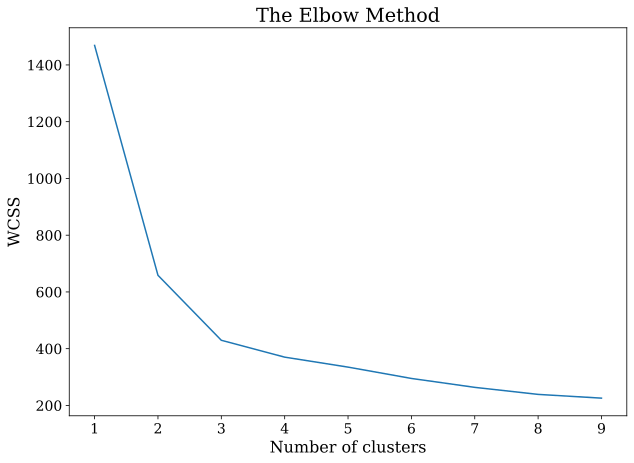

In [42]:
elbow_method(X_pca2, 10)

In [44]:
model2 = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_hat2 = model2.fit_predict(X_pca2)

Cluster 0 correspond to 2 samples of grain type 1
Cluster 0 correspond to 66 samples of grain type 2
Cluster 0 correspond to 0 samples of grain type 3
Cluster 1 correspond to 4 samples of grain type 1
Cluster 1 correspond to 0 samples of grain type 2
Cluster 1 correspond to 65 samples of grain type 3
Cluster 2 correspond to 64 samples of grain type 1
Cluster 2 correspond to 4 samples of grain type 2
Cluster 2 correspond to 5 samples of grain type 3
              precision    recall  f1-score   support

           1       0.88      0.91      0.90        70
           2       0.97      0.94      0.96        70
           3       0.94      0.93      0.94        70

    accuracy                           0.93       210
   macro avg       0.93      0.93      0.93       210
weighted avg       0.93      0.93      0.93       210



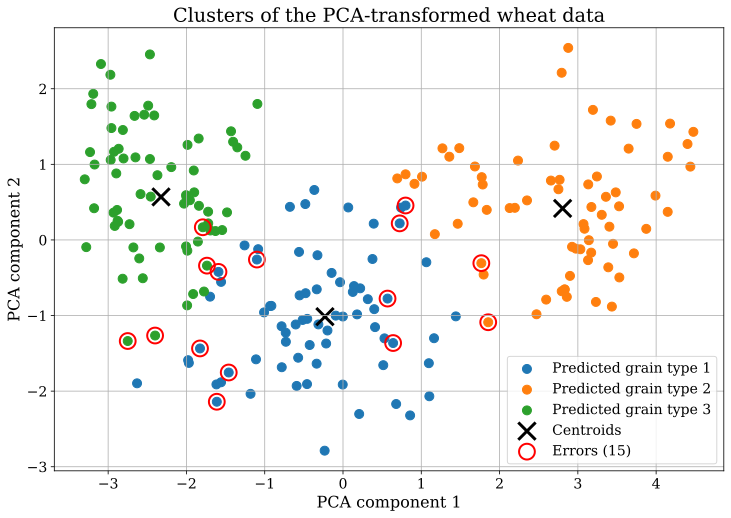

In [45]:
# compare with true data
df = pd.DataFrame({
    "true": y,
    "predicted": y_hat2,
})
df

# find out which cluster represent which grain type
for c in range(3):
    for g in range(1, 4):
        N = (df.true[df.predicted==c] == g).sum()
        print(f"Cluster {c} correspond to {N} samples of grain type {g}")

# remap clusters to grain types
def remap(c):
    if c==0:
        return 2
    elif c==1:
        return 3
    elif c==2:
        return 1
    else:
        raise ValueError("Cannot be anything aprt from 0, 1, and 2")

df2 = df.copy()
df2.predicted = df2.predicted.apply(remap)

# get metrics
from sklearn.metrics import classification_report

print(classification_report(df2.true, df2.predicted))

# plot the clusters, their centroids, and the errors
centroids = model.cluster_centers_
errors = (df2.predicted != df2.true).values

fig = plt.figure(figsize=(12, 8))

# samples colored by the predicted grain type
for g in range(1, 4):
    mask = (df2.predicted == g).values
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=80, label='Predicted grain type ' + str(g))

# centroids, annotated with the grain type they were remapped to
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='k', marker='x',
            linewidths=3, label='Centroids')

# circle the samples where the predicted grain type is wrong
plt.scatter(X_pca[errors, 0], X_pca[errors, 1], s=250, facecolors='none', edgecolors='r',
            linewidths=2, label='Errors (' + str(errors.sum()) + ')')

plt.title('Clusters of the PCA-transformed wheat data')
plt.xlabel('PCA component 1')
plt.ylabel('PCA component 2')
plt.grid(True)
plt.legend()
plt.show()



_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - Foundations of AI_  \
_Notebook: 3a_Unsupervised_learning_

_References:_
- _Scikit-learn documentation, https://scikit-learn.org/stable/index.html_
- _SciPy documentation, https://docs.scipy.org/doc/scipy/index.html_

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_

